In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#import du fichier billets_nettoye.csv

df_billets = pd.read_csv('/content/drive/MyDrive/Projet_Detection_Billet/billets_nettoye.csv')
df_billets.head()

,Unnamed: 0,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [4]:
#Suppression de la colonne Unnamed: 0
df_billets = df_billets.drop('Unnamed: 0', axis=1)

In [5]:
df_billets.tail()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25
1499,False,171.47,104.15,103.82,4.63,3.37,112.07


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, marge, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

In [6]:
#Prétraitement

# les variables prédictives
X = df_billets[['diagonal','height_left','height_right','margin_low','margin_up','length']]
X.shape


(1500, 6)

In [7]:
# la variable cible, is_genuine
y = df_billets.is_genuine
y

,is_genuine
0,True
1,True
2,True
3,True
4,True
...,...
1495,False
1496,False
1497,False
1498,False


In [8]:
#Prétraitement de la varibale cible --> transformer True en 1 et False en 0

y = df_billets['is_genuine'].astype(int).values
y


array([1, 1, 1, ..., 0, 0, 0])

In [9]:
#on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

# train_test_split
#train_test_split permet de séparer les données en un jeu d’entraînement et un jeu de test afin d’évaluer
#la performance du modèle sur des données jamais vues
#Le random_state sert à garantir la reproductibilité des résultats. Sa valeur n’a pas d’importance, tant qu’elle est fixée.

from sklearn.model_selection import train_test_split

#Echantillon traitement 80% et Echantillon test 20%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


***Les données ont été séparées une seule fois en ensembles d’entraînement et de test.***

***Puis, on va entraîner et évaluer plusieurs algorithmes de classification sur cette même séparation afin de garantir une comparaison équitable des performances.***

In [10]:
X_train.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,171.957067,104.030342,103.919958,4.473925,3.150933,112.690067
std,0.307434,0.301215,0.326365,0.654201,0.231815,0.879176
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.490000
25%,171.750000,103.820000,103.707500,4.010000,2.990000,112.057500
50%,171.960000,104.040000,103.920000,4.320000,3.130000,112.980000
75%,172.170000,104.230000,104.150000,4.792500,3.310000,113.350000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.320000


***Les données  vont être standardisées pour garantir une contribution équilibrée des variables et une optimisation stable du modèle.***

***Les variables ont été centrées et réduites à l’aide du StandardScaler afin de garantir une contribution équilibrée des variables aux algorithmes supervisé ou les non supervisés.***

***On a choisi StandardScaler plutôt que MinMaxScaler car il centre et réduit les variables en conservant leur structure de variance, ce qui est essentiel pour les modèles basés sur les distances et l’analyse statistique (K-means, KNN, régression logistique). Or MinMaxScaler transforme les données en les ramenant dans un intervalle fixe (généralement [0,1]) en utilisant les valeurs minimale et maximale de chaque variable.***

In [11]:
# Mettre les variables sur la même échelle
##On espère avoir une moyenne à 0 et un écart type à 1

from sklearn.preprocessing import StandardScaler

#scaler
scaler = StandardScaler()

# fit uniquement sur le train
X_train_scaled = scaler.fit_transform(X_train)

X_train_scaled[:5]


array([[ 1.05085314,  1.95841641, -0.36771166, -0.60239753, -0.30611809,
         0.64852865],
       [-0.18569989,  1.55986362, -1.31796341, -0.60239753, -1.42816747,
         0.92162529],
       [-1.06430336,  0.99524718,  2.1152042 ,  0.62097753,  0.85908704,
        -0.60316427],
       [ 0.33495401,  0.82918353,  1.19560573,  1.73730728,  0.51384107,
        -1.22901072],
       [ 0.46511749,  1.29416177, -0.98077731, -0.44947564, -1.12607725,
         0.71680281]])

In [12]:
# transform sur le test
X_test_scaled = scaler.transform(X_test)
X_test_scaled[:5]

array([[ 0.9857714 , -0.43290028,  0.61319337,  0.78919161,  1.16117725,
        -1.61589763],
       [-0.99922162,  0.96203445,  1.4101787 ,  1.79847603,  0.38437384,
        -0.44385789],
       [-1.38971205, -1.66177136, -0.88881746, -0.66356628, -0.82398703,
         0.07957733],
       [ 1.11593487, -1.23000584, -1.28731013,  0.02458219,  0.03912788,
         0.29577883],
       [ 0.69290357, -0.79824033, -1.164697  , -0.61768971, -1.60079045,
         0.38681104]])

In [13]:
##On espère avoir une moyenne à 0 et un écart type à 1
#Vérification du scaling en regardant les moyennes proches de 0 et les écarts-types proches de 1 sur le jeu d’entraînement
pd.DataFrame(X_train_scaled).describe().round(2).iloc[1:3:, : ]

,0,1,2,3,4,5
mean,0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


In [14]:
#Revenir à un Dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns,index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)


In [15]:
X_train_scaled.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03
mean,1.534476e-14,-1.739201e-14,2.077153e-14,-5.625130e-16,8.422892e-16,-1.596353e-14
std,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00
min,-2.984215e+00,-2.957068e+00,-3.371733e+00,-2.284538e+00,-3.801733e+00,-3.641364e+00
25%,-6.738129e-01,-6.986021e-01,-6.512545e-01,-7.094428e-01,-6.945198e-01,-7.197993e-01
50%,9.545322e-03,3.207796e-02,1.277220e-04,-2.353850e-01,-9.033936e-02,3.299159e-01
75%,6.929036e-01,6.631199e-01,7.051532e-01,4.871709e-01,6.864641e-01,7.509399e-01
max,3.426337e+00,2.821947e+00,3.157416e+00,3.710000e+00,3.275809e+00,1.854705e+00


Dans notre jeu de données, la classe numéro 1 (positive) correspond aux vrais billets et la classe numéro 0 (négative) correspond aux faux billets.

Dans ce projet, mieux vaut accuser à tort un vrai billet que de laisser passer un faux billet.

L'erreur qui se présentera sera d'avoir des faux négatifs (FN) et des faux positifs (FP).

***--> L’erreur la plus critique étant la classification d’un faux billet comme vrai billet (faux positif), nous cherchons  ,alors, à minimiser les faux positifs, ce qui justifie l’optimisation de la précision.***

In [16]:
# Préparation des données

# Affectation pour la regression logistique
X_train_scaled_log = X_train_scaled
y_train_log = y_train
X_test_scaled_log = X_test_scaled
y_test_log = y_test

# Affectation pour le kmeans

X_train_scaled_kmeans = X_train_scaled
y_train_kmeans = y_train
X_test_scaled_kmeans = X_test_scaled
y_test_kmeans = y_test

# Affectation pour le KNN
X_train_scaled_KNN = X_train_scaled
y_train_KNN = y_train
X_test_scaled_KNN = X_test_scaled
y_test_KNN = y_test

# Affectation pour le Random Forest
X_train_scaled_Ran = X_train_scaled
y_train_Ran = y_train
X_test_scaled_Ran = X_test_scaled
y_test_Ran = y_test




On commence par un modèle simple qui sert de référence/benchmark.
Ensuite, on teste des modèles plus complexes pour voir s’ils apportent réellement une amélioration mesurable par rapport à cette base

***1- Regression Logistique : C'est un algorithme de classification supervisée qui aide à prédire qu'une donnée appartient à une catégorie***

In [17]:
from sklearn.linear_model import LogisticRegression

# initialisation et entraînement en une ligne
#Le random_state permet de garantir la reproductibilité des résultats en contrôlant la part aléatoire de l’algorithme.
#Sa valeur n’a pas d’importance tant qu’elle est fixée : random_state=8

model_1 = LogisticRegression(random_state=8).fit(X_train_scaled_log, y_train_log)


In [18]:
# prediction sur le set de test
# predict renvoie la classe finale tandis que predict_proba renvoie la probabilité associée à chaque classe.


y_pred_log = model_1.predict(X_test_scaled_log)



In [19]:
#  predict_proba est indispensable pour les métriques comme la ROC-AUC et pour ajuster le seuil de décision.

y_pred_proba_log = model_1.predict_proba(X_test_scaled_log)


<Axes: ylabel='Count'>

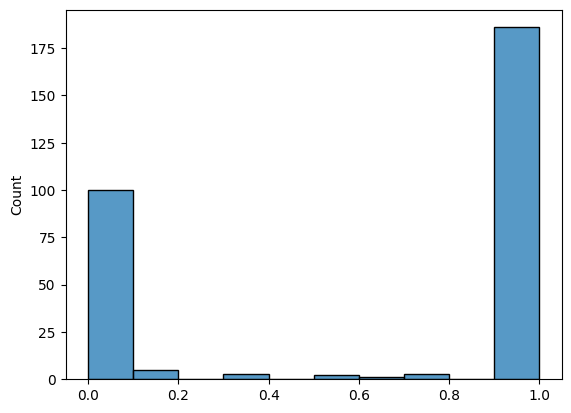

In [20]:
#Histogrammes des probabilités
y_hat_proba = model_1.predict_proba(X_test_scaled_log)[:,1]
import seaborn as sns
sns.histplot(y_hat_proba)

Le modèle est assez fiable au niveau de ses prédictions, la plupart des prédictions ont une probabilité proche de 0 ou de 1.

In [21]:
# Accuracy (L'Exactitude): Echantillon Bien classés/Echantillon Total = TP+TN/Total
# L’accuracy doit être calculée sur le jeu de test en comparant y_test aux prédictions y_pred,
# afin d’évaluer la capacité de généralisation du modèle



from sklearn.metrics import accuracy_score
accuracy_score(y_test_log, y_pred_log)

print("accuracy",accuracy_score(y_test_log, y_pred_log))

accuracy 0.9933333333333333


Le plus simple pour mesurer la performance d'une classification est de regarder le nombre d'échantillons qui ont été correctement classés. C'est l'exactitude (accuracy, en anglais).

exactitude = échantillons bien classés / échantillons au total
--> accuracy 0.993: Pas Mal !!!

In [22]:
# Matrice de confusion

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_log, y_pred_log)

array([[108,   2],
       [  0, 190]])

Pour 20% (échantillon du test): 300 billets

TN(True Negatif): 108 --> Les fausses billets qui sont bien fausses.

TP (True positif): 190 --> Les vrais billets qui sont vrais.

FP (False Positif): 2 --> 2  faux billets prédits vrais ! Faire Attention

FN (False Negatif): 0

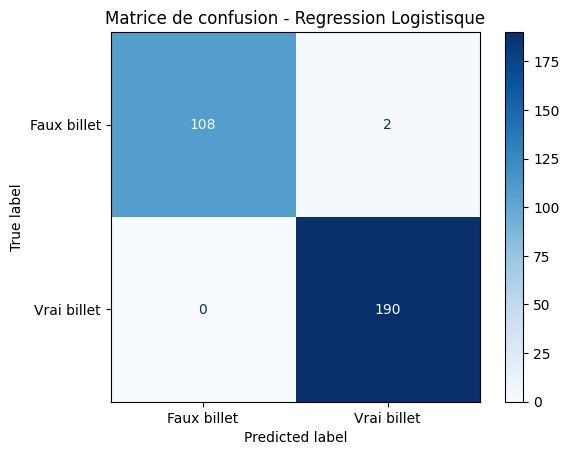

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_log, y_pred_log)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Faux billet", "Vrai billet"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Regression Logistisque")
plt.show()

In [24]:
# Autres métriques : Précision, Recall
#NB : Recall est utilisé pour minimiser les FN or dans notre cas FN sont à 0
#NB : Precision est utilisé pour minimiser les FP

from sklearn.metrics import precision_score, recall_score, roc_auc_score
print("Precision:",precision_score(y_test_log, y_pred_log))
print("Recall:",recall_score(y_test_log, y_pred_log))


Precision: 0.9895833333333334
Recall: 1.0


Precision élevée → peu de faux positifs

Recall = 1 → peu de faux négatif

Ensemble → modèle quasi parfait


In [25]:
print("ROC-AUC", roc_auc_score(y_test_log, model_1.predict_proba(X_test_scaled_log)[:, 1]))

ROC-AUC 0.9998564593301436


Un ROC-AUC de 0.999 indique une excellente capacité de discrimination, mais un score aussi proche de 1 doit être analysé avec prudence car il peut révéler une fuite d’information ou un surapprentissage

L'idée est de tracer le rappel ou TPR (true positive rate) par rapport au FPR (false positive rate) en fonction des seuils de classification. Le TPR est défini par TP / (TP + FN) et le FPR est défini par FP (FP + TN).

Text(0.5, 1.0, 'ROC curve')

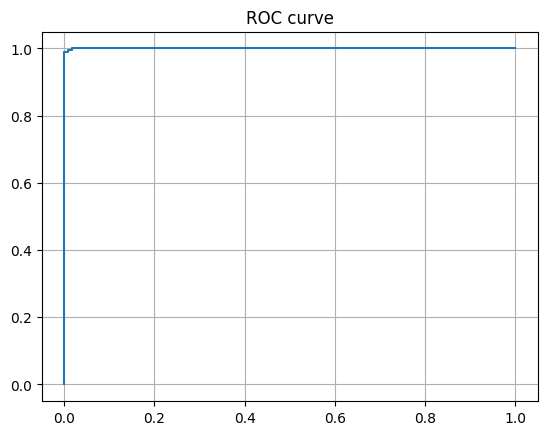

In [26]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test_log, model_1.predict_proba(X_test_scaled_log)[:,1])

import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.grid()
plt.title("ROC curve")

Plus la courbe se rapproche du coin en haut à gauche, meilleur est le modèle

L’axe des abscisses représente le taux de faux positifs, tandis que l’axe des ordonnées représente le taux de vrais positifs.

La courbe ROC permet d’analyser le compromis entre détection correcte et erreurs de classification selon différents seuils de décision.

In [27]:
from sklearn.metrics import classification_report

# Calculez le classification_report
report = classification_report(y_test_log, y_pred_log)

# Affichez le rapport
print(report)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       110
           1       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



***2 - Kmeans : C'est un algorithme de classification non supervisée qui regroupe les individus en K groupes en fonction de leur similarité, en minimisant la distance entre chaque individu et le centroïde de son cluster.***

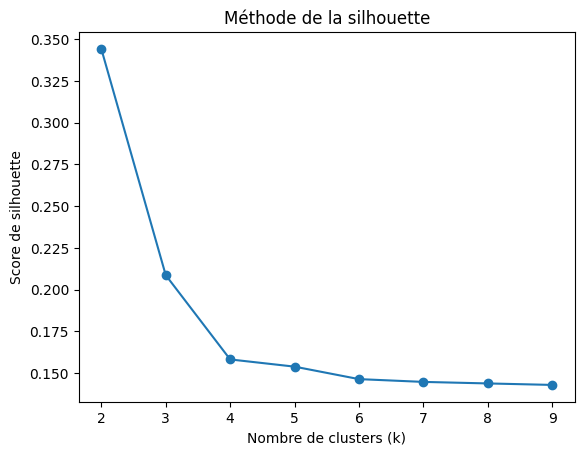

In [28]:
# Calcul du score de silhouette pour plusieurs k

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train_scaled_kmeans)
    score = silhouette_score(X_train_scaled_kmeans, labels)
    scores.append(score)

plt.plot(K, scores, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Méthode de la silhouette")
plt.show()

On choisit le k qui maximise le score de silhouette: K = 2

--> Le coefficient de silhouette est maximal pour k = 2, indiquant une séparation naturelle des billets en deux groupes distincts: vrai billets et Faux billets.

In [29]:
model_2 = KMeans(n_clusters=2, n_init="auto")
model_2.fit(X_train_scaled_kmeans)

KMeans(n_clusters=2)

In [30]:
# Voici les scores de classification
print("score", model_2.score(X_train_scaled_kmeans))
print("silhouette_score: ", silhouette_score(X_train_scaled_kmeans,model_2.labels_ ))

score -4674.309516411701
silhouette_score:  0.34424534720226035


Un score de silhouette de 0.34 indique une séparation modérée des clusters, traduisant un chevauchement partiel entre les vrais billets et les faux.

In [31]:
#Réaliser un tableau de contingence  en croisant les clusters issus de K-means
#avec les classes réelles afin d’évaluer la cohérence entre structure non supervisée et la réalité métier.

#kmeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled_kmeans)


table_contingence = pd.crosstab(
    clusters,
    y_train_kmeans,
    rownames=['Cluster K-means'],
    colnames=['Classe réelle']
)

print(table_contingence)

Classe réelle      0    1
Cluster K-means          
0                377    4
1                 13  806


- Cluster 0 :  377 faux et 4 vrais --> cluster 0 correspond majoritairement aux faux billets.

- Cluster 1 : 13 faux et 806 vrais --> cluster 1 correspond majoritairement aux vrais billets.

➡️ clusters bien homogènes

➡️ très peu de chevauchement

 --> Les clusters identifiés par le KMeans coïncident naturellement avec les classes réelles.

In [32]:
# Match categories de kmeans avec les bonnes  categories du dataset


mapping = {0: 0, 1: 1}

In [33]:
# Appliquer le mapping
import numpy as np

clusters_inverted = np.vectorize(mapping.get)(clusters)


# Vérification de la nouvelle table de contingence
pd.crosstab(
    clusters_inverted,
    y_train_kmeans,
    rownames=['Cluster mappé'],
    colnames=['Classe réelle']
)


Classe réelle,0,1
Cluster mappé,,
0,377,4
1,13,806


In [34]:
# KMeans entraîné sur le train
kmeans.fit(X_train_scaled_kmeans)

KMeans(n_clusters=2, random_state=42)

In [35]:
# Prédictions sur le test
clusters_test = kmeans.predict(X_test_scaled_kmeans)
clusters_test.size

300

In [36]:
# Mapping cluster → classe

y_pred_kmeans = pd.Series(clusters_test).map(mapping)
y_pred_kmeans.size

300

***Les performances du KMeans sont évaluées sur le jeu de test à partir des clusters prédits, après correspondance avec les classes réelles.***

Bien que le K-means soit un algorithme non supervisé, nous l’utilisons de manière indirecte à des fins prédictives. Les centroïdes sont appris sur les données d’entraînement, puis les clusters sont associés aux classes réelles à partir du train. Cette correspondance permet ensuite d’évaluer les performances sur le jeu de test, tout en respectant la séparation train/test.

In [37]:
# Les métriques

from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test_kmeans, y_pred_kmeans)
precision = precision_score(y_test_kmeans, y_pred_kmeans)
recall = recall_score(y_test_kmeans, y_pred_kmeans)

print(f"Accuracy : {accuracy:.3f}")
print(f"precision : {precision:.3f}")
print(f"recall : {recall:.3f}")

Accuracy : 0.990
precision : 0.995
recall : 0.989


une performance assez bonne avec une exactitude de 0.99

In [38]:
# Matrice de confusion

from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test_kmeans, y_pred_kmeans)
print(conf_matrix)

[[109   1]
 [  2 188]]


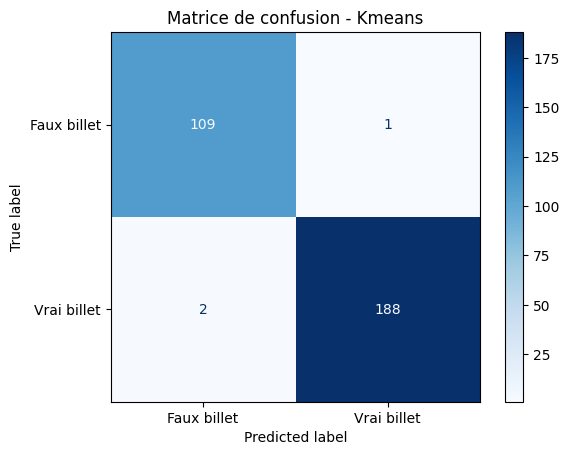

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_kmeans, y_pred_kmeans)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Faux billet", "Vrai billet"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Kmeans")
plt.show()

***Comparaisons Régression logistique vs Kmeans***

- Même sans connaître la classe, K-means :retrouve presque parfaitement la séparation vrai/faux et cela uniquement à partir des dimensions physiques -- > les dimensions des billets portent une information intrinsèquement discriminante.

- Accuracy K-means ≈ 99 %  et Accuracy Logistique ≈ 99,3 %
--> Les résultats sont cohérents que la technique soit supervisée ou non supervisée.

en kmeans : [[109   1]
 [  2 188]]

en Regression logistique :[[108,   2],
       [  0, 190]]


- L'erreur (FN+FP) avec la regression logistique est 3 or l'erreur  (FN+FP) avec K-means 4 --> Notre but étant de minimiser les faux billets le plus possible : la régression logistique est plus performante.

***Description des clusters par des boxplots***

In [40]:
# Récupérer les clusters du train

kmeans = KMeans(n_clusters=2, random_state=42)
clusters_train = kmeans.fit_predict(X_train_scaled_kmeans)

In [41]:
# Création d'un Dataframe pour l'analyse
# Pour l'analyse nous avons besoin des données originales non scalées

df_kmeans = X_train.copy()   # données originales
df_kmeans["cluster"] = clusters_train

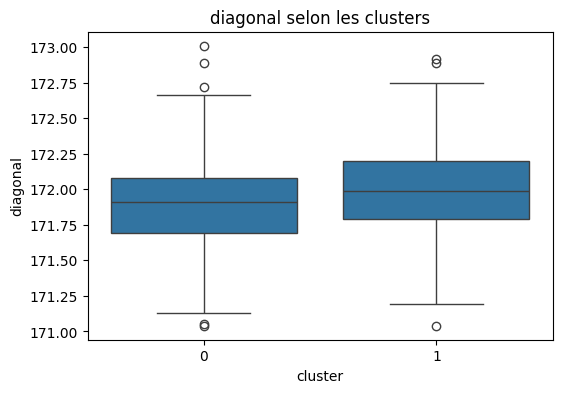

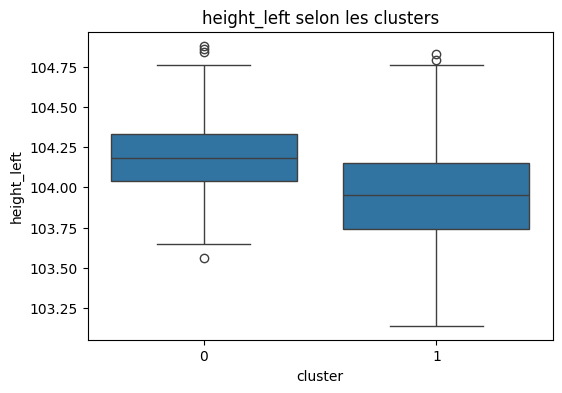

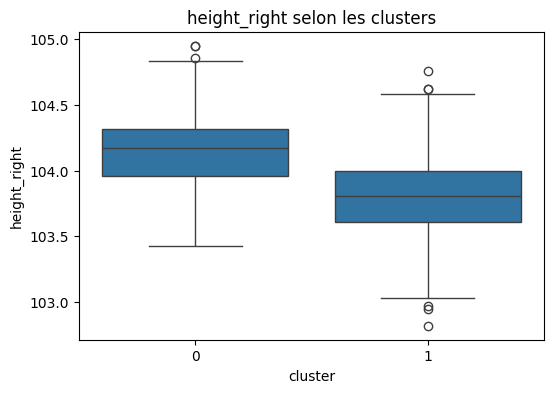

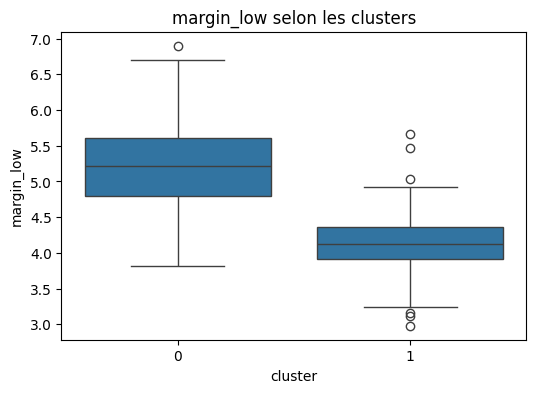

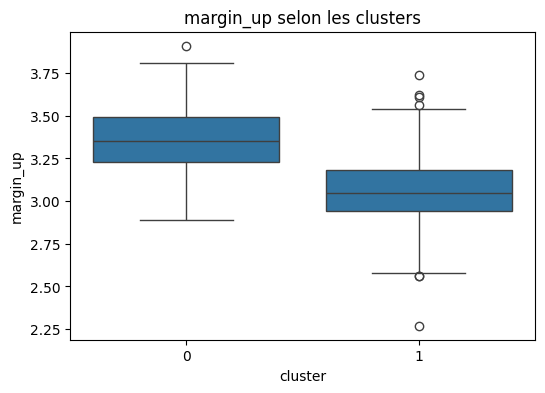

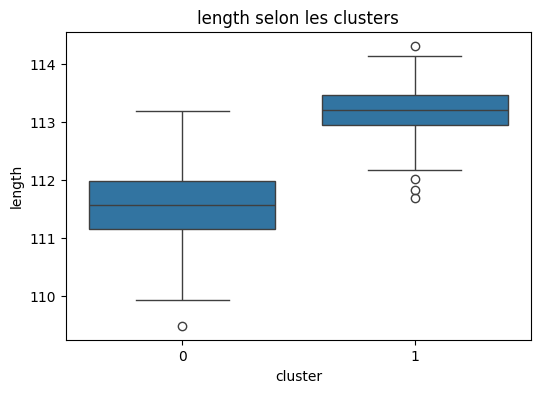

In [42]:
variables = X_train.columns

for var in variables:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="cluster", y=var, data=df_kmeans)
    plt.title(f"{var} selon les clusters")
    plt.show()



- La comparaison entre les boxplots des classes réelles et ceux issus du clustering montre que l’algorithme K-means parvient à retrouver une structure proche de la réalité.

- Les dimensions apparaîssent comme des variables discriminantes, capable de séparer naturellement les billets en deux groupes distincts : des vrais billets et des faux billets avec l'existence d'un chevauchement partiel.

***Projections des clusters du test***


In [43]:
#Réalisation d'une ACP pour visualiser la projection des billets (de la partie test)avant et après le clustering par kmeans

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled_kmeans)
X_test_pca = pca.transform(X_test_scaled_kmeans)


In [44]:
# Récupérer les clusters du train

kmeans = KMeans(n_clusters=2, random_state=42)
clusters_train = kmeans.fit_predict(X_train_scaled_kmeans)

In [45]:
#Clusters prédits sur le test
labels_test = kmeans.predict(X_test_scaled_kmeans)

In [46]:
# Projection des centroïdes dans l’espace ACP
centroids_scaled = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


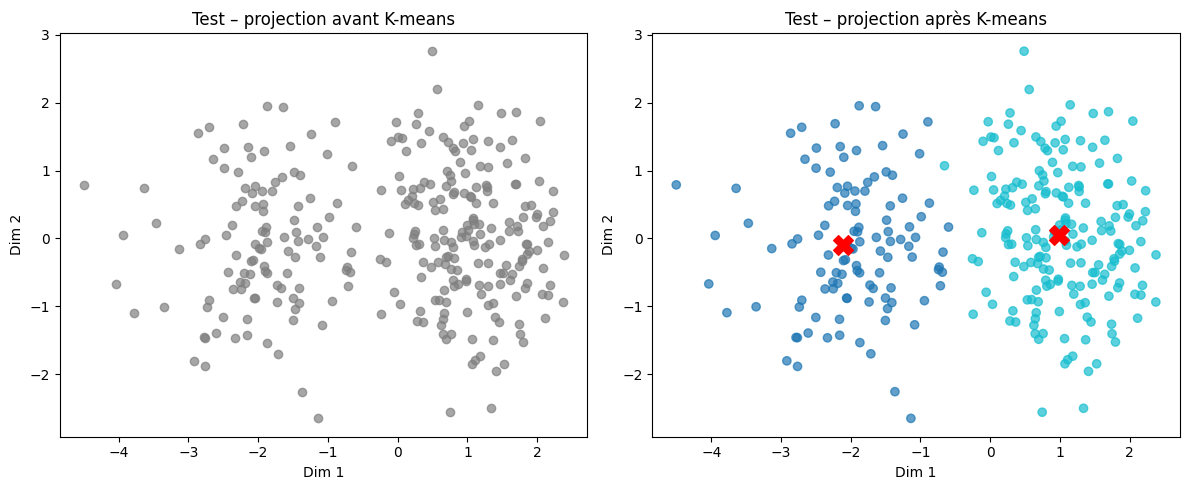

In [47]:
# Projection des billets et comparaison


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AVANT K-means (test, sans clustering)
axes[0].scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    color="gray",
    alpha=0.7
)
axes[0].set_title("Test – projection avant K-means")
axes[0].set_xlabel("Dim 1")
axes[0].set_ylabel("Dim 2")

# APRÈS K-means (test, clusters prédits)
axes[1].scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=labels_test,
    cmap="tab10",
    alpha=0.7
)

# Centroïdes
axes[1].scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    s=200,
    marker="X",
    label="Centroïdes"
)


axes[1].set_title("Test – projection après K-means")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")

plt.tight_layout()

#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Test_projection_K-means.png", dpi=300, bbox_inches="tight")
plt.show()


La comparaison des projections avant et après clustering montre que le K-means, entraîné sur l’échantillon d’apprentissage, parvient à structurer efficacement les données du jeu de test. Les clusters obtenus sont compacts, bien séparés et alignés avec la première dimension de l’ACP, indiquant une bonne capacité de généralisation du modèle

***3 - KNN: C'est un algorithme de classification supervisée qui prédit la classe d’une observation en fonction des K observations les plus proches dans le jeu d’apprentissage (dis-moi qui sont tes voisins, je te dirai qui tu es).***

***Choix du K (le nombre de voisins) par GridSearchCV***

Le paramètre K est choisi par GridSearchCV afin d’obtenir le meilleur compromis biais–variance et d’éviter le sur-apprentissage

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Définition du modèle
knn = KNeighborsClassifier()

#paramètre à tester (valuer de K, voisins égaus ou pondérés,distance utilisée)

#Dans KNN, une prédiction est faite à partir des K plus proches voisins.
#Le paramètre weights indique comment chaque voisin contribue à la décision finale.

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# GridSearchCV (SUR LE TRAIN UNIQUEMENT)
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='precision',   # important pour détecter un max de faux billets (FP)
    cv=5,
    n_jobs=-1
)


#Entraînement du GridSearch
grid_knn.fit(X_train_scaled_KNN, y_train_KNN)




GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='precision')

In [49]:
#Meilleurs paramètres trouvés
print("Meilleurs paramètres KNN :", grid_knn.best_params_)
print("Meilleur score CV (precision) :", grid_knn.best_score_)

Meilleurs paramètres KNN : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Meilleur score CV (precision) : 0.990198182718855


Le paramètre K influence fortement les performances du KNN. Plutôt que de fixer arbitrairement une valeur, nous avons utilisé une validation croisée via GridSearchCV afin d’identifier automatiquement le meilleur compromis biais/variance sur les données d’entraînement, en optimisant la précision, critère prioritaire pour la détection de faux billets

In [50]:
# Meilleur modèle KNN optimisé

best_knn = grid_knn.best_estimator_


In [51]:
# Evaluation finale sur le test

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_pred_knn = best_knn.predict(X_test_scaled_KNN)

print("Accuracy :", accuracy_score(y_test_KNN, y_pred_knn))
print("Precision :", precision_score(y_test_KNN, y_pred_knn))
print("Recall :", recall_score(y_test_KNN, y_pred_knn))

confusion_matrix(y_test_KNN, y_pred_knn)


Accuracy : 0.9833333333333333
Precision : 0.9743589743589743
Recall : 1.0


array([[105,   5],
       [  0, 190]])

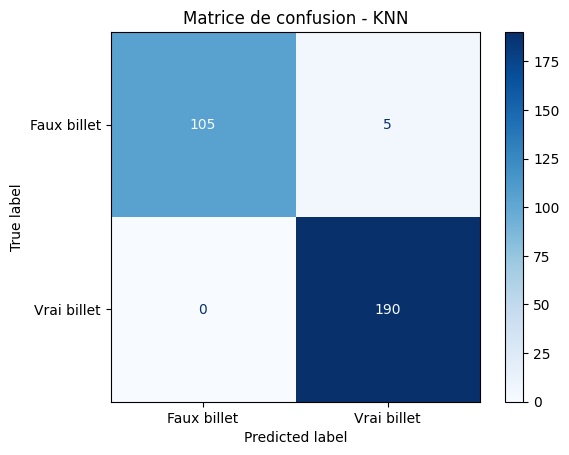

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_KNN, y_pred_knn)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Faux billet", "Vrai billet"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - KNN")
plt.show()

In [53]:
#Prédiction sur le test

y_proba_knn = best_knn.predict_proba(X_test_scaled_KNN)[:, 1]

roc_auc = roc_auc_score(y_test_KNN, y_proba_knn)

print(f"ROC-AUC : {roc_auc:.3f}")


ROC-AUC : 0.995


***4- Random Forest***

Les forêts aléatoires consistent à combiner de nombreuses instances d'arbres de décision entraînées en parallèle.

In [54]:
from sklearn.ensemble import RandomForestClassifier

#Entraînement
#Bien que la standardisation ne soit pas nécessaire pour les modèles basés sur des arbres,
#les données standardisées ont été utilisées afin d’assurer une cohérence entre les différents algorithmes testés,
#sans impact négatif sur les performances du Random Forest.

# Un nombre de 200 arbres permet d’obtenir un modèle robuste et stable sans augmenter excessivement le temps de calcul.
# Le paramètre class_weight='balanced' permet de corriger le déséquilibre entre
#les classes et d’améliorer la détection des billets minoritaires (les faux billets dans notre cas).

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)


rf.fit(X_train_scaled_Ran, y_train_Ran)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [55]:
# Prédiction sur le test

y_pred_rf = rf.predict(X_test_scaled_Ran)
y_proba_rf = rf.predict_proba(X_test_scaled_Ran)[:, 1]


In [56]:
# Les métriques

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test_Ran, y_pred_rf)
precision = precision_score(y_test_Ran, y_pred_rf)
recall = recall_score(y_test_Ran, y_pred_rf)
roc_auc = roc_auc_score(y_test_Ran, y_proba_rf)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall : {recall:.3f}")
print(f"ROC-AUC : {roc_auc:.3f}")


Accuracy : 0.990
Precision : 0.984
Recall : 1.000
ROC-AUC : 1.000


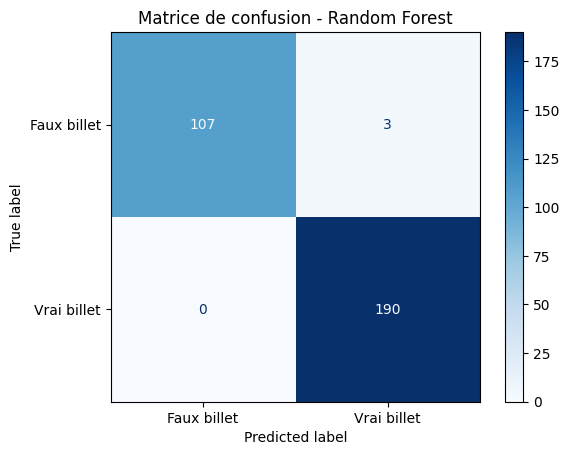

In [57]:
# Matrice de confusion

cm = confusion_matrix(y_test_Ran, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Faux billet", "Vrai billet"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Random Forest")
plt.show()


In [58]:
print(confusion_matrix(y_test_Ran, y_pred_rf))

[[107   3]
 [  0 190]]


***Comparaison des algorithmes en fonction des métriques***

In [59]:
import pandas as pd
from sklearn.metrics import f1_score


# Création d'une fonction d'évaluation
def evaluate_model(name, y_test, y_pred, y_proba=None):
    results = {
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

    if y_proba is not None:
        results["ROC-AUC"] = roc_auc_score(y_test, y_proba)
    else:
        results["ROC-AUC"] = None

    return results


# Liste pour stocker les résultats
results = []

# Régression logistique
results.append(
    evaluate_model(
        "Régression Logistique",
        y_test,
        y_pred_log,
        y_pred_proba_log[:, 1]
    )
)

# KNN
results.append(
    evaluate_model(
        "KNN",
        y_test,
        y_pred_knn,
        y_proba_knn
    )
)

# Random Forest
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_proba_rf
    )
)

# Kmeans
results.append(
    evaluate_model(
        "kmeans",
        y_test,
        y_pred_kmeans,

    )
)

# Création du DataFrame final
df_results = pd.DataFrame(results).set_index("Modèle")

# Arrondi logique (pour le calcul)
df_rounded = df_results.round(2)

def bold_max(s):
    max_val = s.max()
    return ['font-weight: bold' if v == max_val else '' for v in s]

styled_df = (
    df_results
    .style
    .format("{:.2f}")
    .apply(lambda s: bold_max(df_rounded[s.name]), axis=0)
)

styled_df





,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modèle,,,,,
Régression Logistique,0.99,0.99,1.00,0.99,1.00
KNN,0.98,0.97,1.00,0.99,0.99
Random Forest,0.99,0.98,1.00,0.99,1.00
kmeans,0.99,0.99,0.99,0.99,nan


Afin de garantir une comparaison équitable, l’ensemble des modèles a été évalué sur le même jeu de test

Les performances des différents algorithmes supervisés et non supervisé ont été comparées à l’aide de métriques communes sur le jeu de test.

Les performances des modèles ont été évaluées à l’aide de plusieurs métriques, notamment l’accuracy, la précision, le rappel, le F1-score et le ROC-AUC. Bien que l’ensemble des méthodes supervisées affiche des résultats élevés, la régression logistique présente la meilleure précision, ce qui est particulièrement pertinent dans un contexte de détection de faux billets où l’enjeu principal est de limiter les faux positifs.

Le K-means, en tant qu’algorithme non supervisé, a été utilisé à des fins exploratoires mais n’a pas été retenu pour la prédiction finale, car il ne s’appuie pas sur les classes réelles et ne garantit pas une décision fiable en production malgré qu'il a une précision élevée.

En conséquence, la régression logistique a été choisie comme modèle final, car elle combine performance élevée, robustesse et interprétabilité, répondant ainsi aux exigences statistiques et opérationnelles du projet.

In [60]:
# Import du modèle de la Régression logistique afin de le réutiliser dans l'application pour détécter les faux billets

#Recréer un Pipeline propre

#Le fitter sur les données non scaled

#L’exporter avec joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

# Recréation propre du pipeline pour export
export_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=model_1.C,
        penalty=model_1.penalty,
        solver=model_1.solver,
        max_iter=model_1.max_iter
    ))
])

# Fit sur les données NON normalisées
export_pipeline.fit(X_train, y_train)

# Sauvegarde
joblib.dump(export_pipeline, "modele_regression_with_pipeline.pkl")

print("✅ Modèle pipeline exporté avec succès")


✅ Modèle pipeline exporté avec succès


In [61]:
# La réutilisation du modèle se fera à travers le fichier modele_regression_with_pipeline.pkl qu'on va télécharger

from google.colab import files
files.download("modele_regression_with_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>